In [21]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [3]:
torch.manual_seed(1337)
np.random.seed(1337)

In [57]:
X, y = make_regression(n_samples=500, n_features=1, noise=10, random_state=1337)

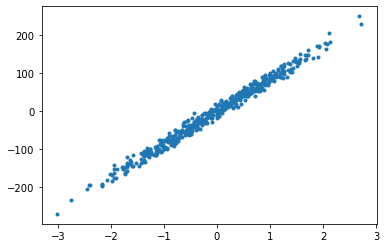

In [58]:
plt.plot(X, y, '.')

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1337)

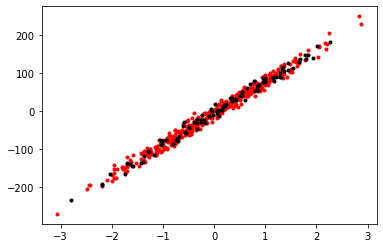

In [96]:
plt.plot(X_train, y_train, 'r.')
plt.plot(X_test, y_test, 'k.')

In [60]:
scaler_X = StandardScaler().fit(X_train)
X_train = scaler_X.transform(X_train)
X_test = scaler_X.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [61]:
class LinearRegression(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return self.linear(x)

In [98]:
model = LinearRegression(n_features=X_train.shape[1])
criteria = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.3)

In [ ]:
epoche = 1000

for ep in range(epoche):
    model.train()
    optimizer.zero_grad()
    predict = model(X_train_t)
    loss = criteria(predict, y_train_t) / X_train_t.shape[0]
    loss.backward()
    optimizer.step()
    if (ep+1) % 100 == 0:
        print(f"Epoche #{ep+1:04}/{epoche} - Loss (MSE): {loss.item():.4f}")

Epoche #0100/1000 - Loss (MSE): 7.7529
Epoche #0200/1000 - Loss (MSE): 2.9803
Epoche #0300/1000 - Loss (MSE): 1.0542
Epoche #0400/1000 - Loss (MSE): 0.4400
Epoche #0500/1000 - Loss (MSE): 0.2887
Epoche #0600/1000 - Loss (MSE): 0.2601
Epoche #0700/1000 - Loss (MSE): 0.2560
Epoche #0800/1000 - Loss (MSE): 0.2555
Epoche #0900/1000 - Loss (MSE): 0.2555
Epoche #1000/1000 - Loss (MSE): 0.2555


In [100]:
model.eval()
with torch.no_grad():
    pred_test = model(X_test_t)
    loss_test = criteria(pred_test, y_test_t) / X_test_t.shape[0]
    print(f"Test MSE: {loss_test.item():.4f}")
    print(f"Weights: {model.linear.weight.detach().numpy()}")
    print(f"Bias: {model.linear.bias.item():.4f}")

Test MSE: 0.8517
Weights: [[82.85883]]
Bias: -4.9223


### Train

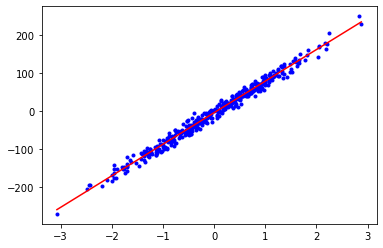

In [101]:
plt.plot(X_train_t, y_train_t, 'b.')
X_lr = torch.tensor(np.linspace(min(X_train_t), max(X_train_t), 50))
w = model.linear.weight.detach().numpy()[0,0]
b = model.linear.bias.item()
# plt.plot(X_lr * w + b, X_lr)
with torch.no_grad():
    plt.plot(X_lr, model(X_lr), 'r')

### Test

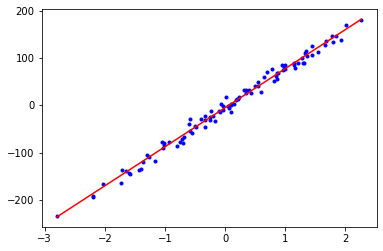

In [102]:
plt.plot(X_test_t, y_test_t, 'b.')
X_lr = torch.tensor(np.linspace(min(X_test_t), max(X_test_t), 50))
w = model.linear.weight.detach().numpy()[0,0]
b = model.linear.bias.item()
# plt.plot(X_lr * w + b, X_lr)
with torch.no_grad():
    plt.plot(X_lr, model(X_lr), 'r')

### High dimension example

In [107]:
X, y = make_regression(n_samples=10_000, n_features=10, noise=10, random_state=1337)

In [108]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1337)

In [109]:
scaler_X = StandardScaler().fit(X_train)
X_train = scaler_X.transform(X_train)
X_test = scaler_X.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [110]:
model = LinearRegression(n_features=X_train.shape[1])
criteria = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.3)

In [111]:
epoche = 1000

for ep in range(epoche):
    model.train()
    optimizer.zero_grad()
    predict = model(X_train_t)
    loss = criteria(predict, y_train_t) / X_train_t.shape[0]
    loss.backward()
    optimizer.step()
    if (ep+1) % 100 == 0:
        print(f"Epoche #{ep+1:04}/{epoche} - Loss (MSE): {loss.item():.4f}")

Epoche #0100/1000 - Loss (MSE): 3.3647
Epoche #0200/1000 - Loss (MSE): 1.3870
Epoche #0300/1000 - Loss (MSE): 0.4951
Epoche #0400/1000 - Loss (MSE): 0.1563
Epoche #0500/1000 - Loss (MSE): 0.0487
Epoche #0600/1000 - Loss (MSE): 0.0203
Epoche #0700/1000 - Loss (MSE): 0.0140
Epoche #0800/1000 - Loss (MSE): 0.0128
Epoche #0900/1000 - Loss (MSE): 0.0126
Epoche #1000/1000 - Loss (MSE): 0.0126


In [112]:
model.eval()
with torch.no_grad():
    pred_test = model(X_test_t)
    loss_test = criteria(pred_test, y_test_t) / X_test_t.shape[0]
    print(f"Test MSE: {loss_test.item():.4f}")
    print(f"Weights: {model.linear.weight.detach().numpy()}")
    print(f"Bias: {model.linear.bias.item():.4f}")

Test MSE: 0.0486
Weights: [[93.78289   24.918335  87.16297    3.0777428 92.921906  99.26242
  72.62483   80.6704    14.118265  96.28241  ]]
Bias: -2.0776
